In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
boston_df = pd.read_csv(boston_url)

print("First 5 rows of Boston Housing Dataset:")
print(boston_df.head())
print("\nDataset Shape:", boston_df.shape)

First 5 rows of Boston Housing Dataset:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Dataset Shape: (506, 14)


In [7]:
X_boston = boston_df.drop("medv", axis=1)
y_boston = boston_df["medv"]

print("Feature Shape:", X_boston.shape)
print("Target Shape:", y_boston.shape)

Feature Shape: (506, 13)
Target Shape: (506,)


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_boston)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_boston,
    test_size=0.20,
    random_state=42
)


print("Training Set Shape:", X_train.shape)

print("Testing Set Shape:", X_test.shape)

Training Set Shape: (404, 13)
Testing Set Shape: (102, 13)


In [13]:
lr_model = LinearRegression()


# Train the model

lr_model.fit(X_train, y_train)


# Predict house prices

lr_predictions = lr_model.predict(X_test)


print("Prediction completed successfully")

Prediction completed successfully


In [15]:
# Calculate evaluation metrics

mae = mean_absolute_error(y_test, lr_predictions)

mse = mean_squared_error(y_test, lr_predictions)

rmse = mse ** 0.5

r2 = r2_score(y_test, lr_predictions)


# Display performance

print("--- Linear Regression Performance ---")

print(f"Mean Absolute Error (MAE): {mae:.4f}")

print(f"Mean Squared Error (MSE): {mse:.4f}")

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

print(f"R² Score: {r2:.4f}")


# Actual vs Predicted values

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": lr_predictions
})


print("\nActual vs Predicted Values:")
print(comparison.head(10))

--- Linear Regression Performance ---
Mean Absolute Error (MAE): 3.1891
Mean Squared Error (MSE): 24.2911
Root Mean Squared Error (RMSE): 4.9286
R² Score: 0.6688

Actual vs Predicted Values:
   Actual Price  Predicted Price
0          23.6        28.996724
1          32.4        36.025565
2          13.6        14.816944
3          22.8        25.031979
4          16.1        18.769880
5          20.0        23.254429
6          17.8        17.662538
7          14.0        14.341190
8          19.6        23.013207
9          16.8        20.632456


In [17]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings("ignore")


# Load Boston Housing Dataset from GitHub

boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

boston_df = pd.read_csv(boston_url)


# Display dataset

print("First 5 rows of Boston Housing Dataset:")
print(boston_df.head())


# Dataset shape

print("\nDataset Shape:", boston_df.shape)

First 5 rows of Boston Housing Dataset:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Dataset Shape: (506, 14)


In [19]:
X_boston = boston_df.drop("medv", axis=1)

y_boston = boston_df["medv"]


print("Feature Shape:", X_boston.shape)

print("Target Shape:", y_boston.shape)

Feature Shape: (506, 13)
Target Shape: (506,)


In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_boston)


# Split dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_boston,
    test_size=0.20,
    random_state=42
)


print("Training Set Shape:", X_train.shape)

print("Testing Set Shape:", X_test.shape)

Training Set Shape: (404, 13)
Testing Set Shape: (102, 13)


In [23]:
svr_model = SVR(kernel='rbf')

# Train SVR model

svr_model.fit(X_train, y_train)


# Prediction using SVR

svr_predictions = svr_model.predict(X_test)



# ---------------- Decision Tree Regression ----------------

dt_model = DecisionTreeRegressor(random_state=42)

# Train Decision Tree model

dt_model.fit(X_train, y_train)


# Prediction using Decision Tree

dt_predictions = dt_model.predict(X_test)


print("Both Regression Models Trained Successfully")

Both Regression Models Trained Successfully


In [25]:
# Function for calculating evaluation metrics

def evaluate_model(y_test, predictions):
    
    mae = mean_absolute_error(y_test, predictions)
    
    mse = mean_squared_error(y_test, predictions)
    
    rmse = mse ** 0.5
    
    r2 = r2_score(y_test, predictions)
    
    return mae, mse, rmse, r2



# Evaluate SVR

svr_mae, svr_mse, svr_rmse, svr_r2 = evaluate_model(
    y_test,
    svr_predictions
)


# Evaluate Decision Tree

dt_mae, dt_mse, dt_rmse, dt_r2 = evaluate_model(
    y_test,
    dt_predictions
)



# Create comparison table

comparison_df = pd.DataFrame({

    "Regression Model": [
        "Support Vector Regression (SVR)",
        "Decision Tree Regression"
    ],

    "MAE": [
        svr_mae,
        dt_mae
    ],

    "RMSE": [
        svr_rmse,
        dt_rmse
    ],

    "R2 Score": [
        svr_r2,
        dt_r2
    ]

})


print("--- Performance Comparison of Regression Models ---")

print(comparison_df.to_string(index=False))

--- Performance Comparison of Regression Models ---
               Regression Model      MAE     RMSE  R2 Score
Support Vector Regression (SVR) 2.732769 5.068830  0.649643
       Decision Tree Regression 2.394118 3.227395  0.857963


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")


# Load Boston Housing Dataset

boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

boston_df = pd.read_csv(boston_url)


# Display dataset

print("First 5 rows:")
print(boston_df.head())


print("\nDataset Shape:", boston_df.shape)

First 5 rows:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Dataset Shape: (506, 14)


In [29]:
X = boston_df.drop("medv", axis=1)

y = boston_df["medv"]


# Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


print("Feature Shape:", X_scaled.shape)

print("Target Shape:", y.shape)

Feature Shape: (506, 13)
Target Shape: (506,)


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)


print("Training Set Shape:", X_train.shape)

print("Testing Set Shape:", X_test.shape)



# Initialize Linear Regression Model

lr_model = LinearRegression()


# Train model

lr_model.fit(X_train, y_train)


# Prediction

y_pred = lr_model.predict(X_test)


print("Model training completed")

Training Set Shape: (404, 13)
Testing Set Shape: (102, 13)
Model training completed


In [33]:

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)



print("--- Regression Model Evaluation ---")

print(f"Mean Absolute Error (MAE): {mae:.4f}")

print(f"Mean Squared Error (MSE): {mse:.4f}")

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

print(f"R² Score: {r2:.4f}")

--- Regression Model Evaluation ---
Mean Absolute Error (MAE): 3.1891
Mean Squared Error (MSE): 24.2911
Root Mean Squared Error (RMSE): 4.9286
R² Score: 0.6688


--- Learning Curve Data ---
   Training Size  Training Error(MSE)  Validation Error(MSE)
0             40             3.099971           3.761168e+23
1             80             5.088300           1.812293e+03
2            121             5.506830           1.450171e+03
3            202             9.220587           2.001444e+02
4            282            17.925358           1.702237e+02
5            404            20.629894           3.675281e+01


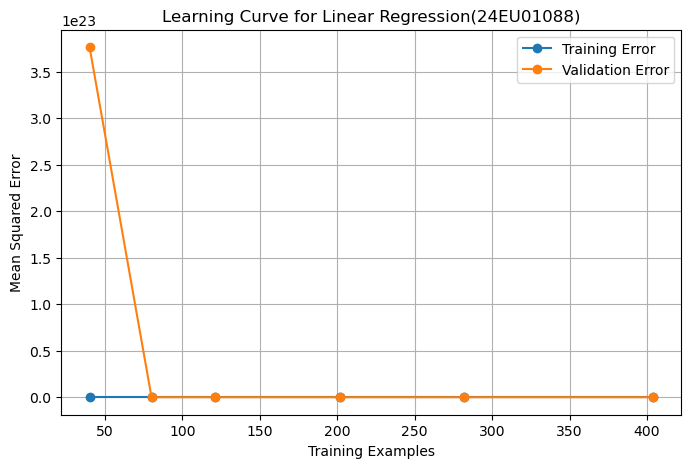

In [37]:
train_sizes, train_scores, test_scores = learning_curve(
    LinearRegression(),
    X_scaled,
    y,
    cv=5,
    scoring='neg_mean_squared_error',
    train_sizes=[0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
)


# Convert negative MSE values to positive

train_errors = -train_scores.mean(axis=1)

test_errors = -test_scores.mean(axis=1)



# Display learning curve values

learning_curve_df = pd.DataFrame({

    "Training Size": train_sizes,

    "Training Error(MSE)": train_errors,

    "Validation Error(MSE)": test_errors

})


print("--- Learning Curve Data ---")

print(learning_curve_df)



# Plot Learning Curve

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_errors,
    marker='o',
    label="Training Error"
)


plt.plot(
    train_sizes,
    test_errors,
    marker='o',
    label="Validation Error"
)

plt.xlabel("Training Examples")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curve for Linear Regression(24EU01088)")
plt.legend()
plt.grid()
plt.show()